In [1]:
# --- Cell 1: Setup ---
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization, Conv2D, MaxPooling2D, Input
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Download Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-gaussian-filtered")
DATA_PATH = os.path.join(path, "gaussian_filtered_images", "gaussian_filtered_images")

print(f"Data ready at: {DATA_PATH}")

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-gaussian-filtered' dataset.
Data ready at: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images


In [2]:
# --- Cell 2: Configuration & Data Loaders ---

# System Configuration
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
NUM_CLIENTS = 3
ROUNDS = 6
EPOCHS_PER_ROUND = 2

def get_generators(model_name):
    """
    Returns training and testing generators with model-specific preprocessing.
    """
    if model_name == 'CustomCNN':
        preprocess_func = None
        rescale_val = 1./255
    elif model_name == 'MobileNetV2':
        preprocess_func = mobilenet_preprocess
        rescale_val = None
    elif model_name == 'VGG16':
        preprocess_func = vgg_preprocess
        rescale_val = None
    elif model_name == 'ResNet50':
        preprocess_func = resnet_preprocess
        rescale_val = None

    # Validation split acts as the hold-out test set for the server
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rescale=rescale_val,
        validation_split=0.2
    )

    train_gen = datagen.flow_from_directory(
        DATA_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
    )

    test_gen = datagen.flow_from_directory(
        DATA_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    return train_gen, test_gen

In [3]:
# --- Cell 3: Model Factory ---

def create_model(model_name, input_shape=(224, 224, 3), num_classes=5):
    """
    Factory function to initialize different model architectures.
    """
    if model_name == 'CustomCNN':
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Conv2D(128, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(num_classes, activation='softmax')
        ])

    else:
        # Transfer Learning models
        if model_name == 'MobileNetV2':
            base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'VGG16':
            base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'ResNet50':
            base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

        base.trainable = False # Freeze base layers for efficiency

        x = GlobalAveragePooling2D()(base.output)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.5)(x)
        out = Dense(num_classes, activation='softmax')(x)
        model = Model(base.input, out)

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Starting Comparative Analysis for: ['CustomCNN', 'MobileNetV2', 'VGG16', 'ResNet50']

   TRAINING MODEL: CustomCNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

--- Round 1/6 ---
   > Client 1 training... 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.1012 | Loss: 5.4263

--- Round 2/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.1012 | Loss: 8.3993

--- Round 3/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.1012 | Loss: 8.8261

--- Round 4/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.1012 | Loss: 6.1416

--- Round 5/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.1409 | Loss: 2.9069

--- Round 6/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... D

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


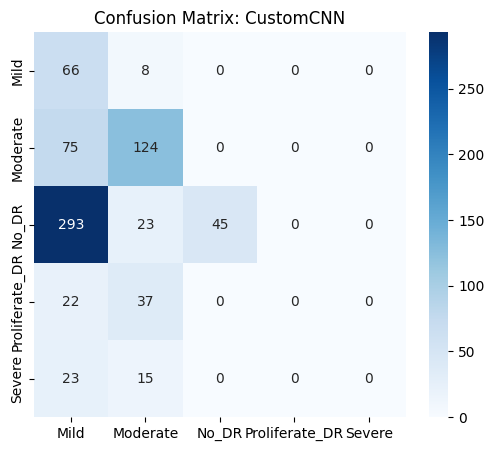


   TRAINING MODEL: MobileNetV2
Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

--- Round 1/6 ---
   > Client 1 training... 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.6977 | Loss: 0.9009

--- Round 2/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7278 | Loss: 0.7932

--- Round 3/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7346 | Loss: 0.7527

--- Round 4/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7442 | Loss: 0.7174

--- Round 5/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7442 | Loss: 0.7015

--- Round 6/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... D

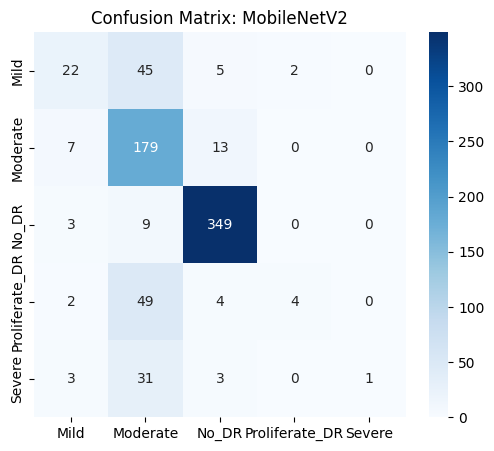


   TRAINING MODEL: VGG16
Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

--- Round 1/6 ---
   > Client 1 training... 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.6621 | Loss: 1.1564

--- Round 2/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.6949 | Loss: 0.9300

--- Round 3/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7127 | Loss: 0.8270

--- Round 4/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7223 | Loss: 0.7775

--- Round 5/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7278 | Loss: 0.7701

--- Round 6/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... D

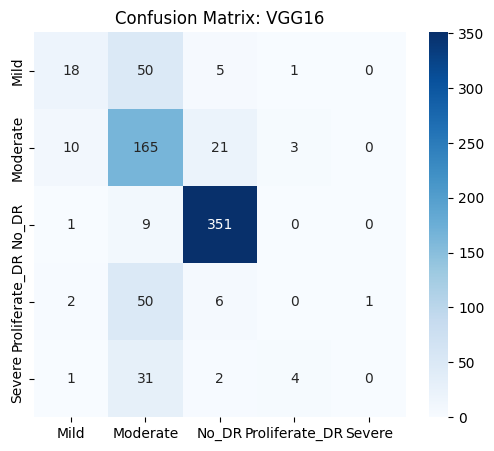


   TRAINING MODEL: ResNet50
Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

--- Round 1/6 ---
   > Client 1 training... 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7182 | Loss: 0.7991

--- Round 2/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7456 | Loss: 0.7186

--- Round 3/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7565 | Loss: 0.6828

--- Round 4/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7661 | Loss: 0.6604

--- Round 5/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... Done.
   > Aggregating updates...
   > Global Accuracy: 0.7620 | Loss: 0.6388

--- Round 6/6 ---
   > Client 1 training... Done.
   > Client 2 training... Done.
   > Client 3 training... D

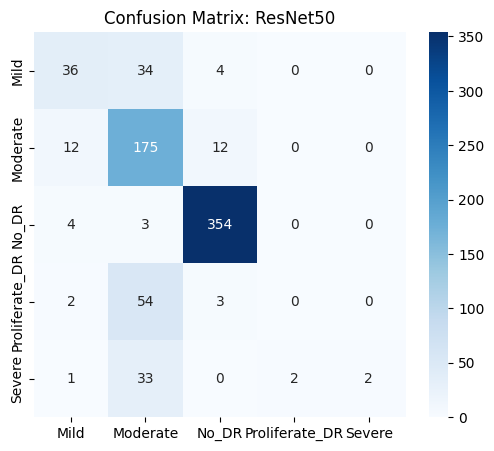

In [4]:
# --- Cell 4: Main Execution Loop ---

models_to_test = ['CustomCNN', 'MobileNetV2', 'VGG16', 'ResNet50']
acc_history_dict = {}
loss_history_dict = {}

print(f"Starting Comparative Analysis for: {models_to_test}")

for model_name in models_to_test:
    print(f"\n=======================================")
    print(f"   TRAINING MODEL: {model_name}")
    print(f"=======================================")

    # Initialize global model and data
    global_model = create_model(model_name)
    train_gen, test_gen = get_generators(model_name)
    global_weights = global_model.get_weights()

    model_accuracies = []
    model_losses = []

    steps_per_client = len(train_gen) // NUM_CLIENTS

    # Federated Training Loop
    for r in range(ROUNDS):
        print(f"\n--- Round {r+1}/{ROUNDS} ---")
        client_weights_list = []
        train_gen.on_epoch_end()

        # Simulate Client Training
        for i in range(NUM_CLIENTS):
            print(f"   > Client {i+1} training...", end=" ")

            local_model = create_model(model_name)
            local_model.set_weights(global_weights)
            local_model.fit(train_gen, steps_per_epoch=steps_per_client, epochs=EPOCHS_PER_ROUND, verbose=0)

            w = local_model.get_weights()
            client_weights_list.append([layer_w * (1.0/NUM_CLIENTS) for layer_w in w])

            # Aggressive Memory Cleanup per Client
            del local_model
            tf.keras.backend.clear_session()
            print("Done.")

        print("   > Aggregating updates...")
        avg_weights = [np.sum(x, axis=0) for x in zip(*client_weights_list)]
        global_model.set_weights(avg_weights)
        global_weights = avg_weights

        loss, acc = global_model.evaluate(test_gen, verbose=0)
        model_accuracies.append(acc)
        model_losses.append(loss)
        print(f"   > Global Accuracy: {acc:.4f} | Loss: {loss:.4f}")

    acc_history_dict[model_name] = model_accuracies
    loss_history_dict[model_name] = model_losses

    # Metrics
    print(f"\n--- Metrics for {model_name} ---")
    test_gen.reset()
    predictions = global_model.predict(test_gen, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

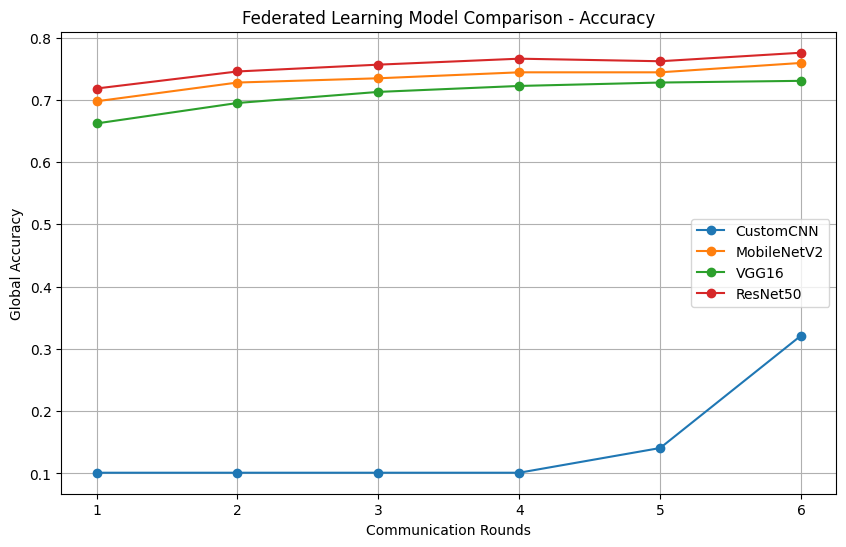

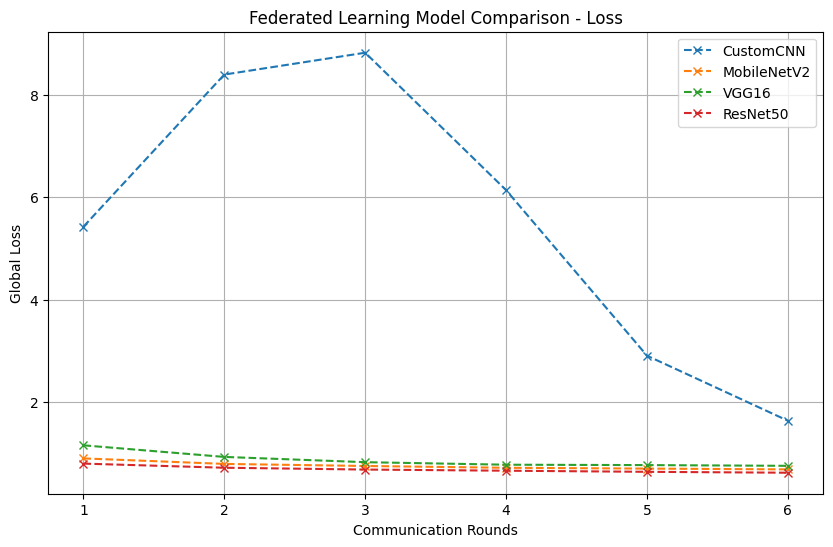


=== FINAL SUMMARY TABLE ===
Model           | Final Accuracy  | Final Loss     
--------------------------------------------------
CustomCNN       | 32.15%          | 1.6365
MobileNetV2     | 75.92%          | 0.6862
VGG16           | 73.05%          | 0.7557
ResNet50        | 77.56%          | 0.6211


In [5]:
# --- Cell 5: Comparative Visualization ---

# 1. Plot Accuracy Comparison
plt.figure(figsize=(10, 6))
for name, accs in acc_history_dict.items():
    plt.plot(range(1, ROUNDS+1), accs, marker='o', label=name)

plt.title('Federated Learning Model Comparison - Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Global Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_comparison.png')
plt.show()

# 2. Plot Loss Comparison
plt.figure(figsize=(10, 6))
for name, losses in loss_history_dict.items():
    plt.plot(range(1, ROUNDS+1), losses, marker='x', linestyle='--', label=name)

plt.title('Federated Learning Model Comparison - Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Global Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_comparison.png')
plt.show()

print("\n=== FINAL SUMMARY TABLE ===")
print(f"{'Model':<15} | {'Final Accuracy':<15} | {'Final Loss':<15}")
print("-" * 50)
for name in acc_history_dict.keys():
    final_acc = acc_history_dict[name][-1]
    final_loss = loss_history_dict[name][-1]
    print(f"{name:<15} | {final_acc*100:.2f}%{' '*9} | {final_loss:.4f}")